In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

In [9]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'

df = pd.read_csv(
    url,
    parse_dates=['ISO_TIME'],    
    usecols=range(12),         
    skiprows=[1],                 
    na_values=[' ', 'NOT_NAMED'], 
    keep_default_na=False,
    dtype={'NAME': str}           
)

df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [10]:
len(df)

716165

In [11]:
df[df['BASIN'] == 'NA'].shape[0]

126392

In [12]:
df['BASIN'].unique()
df['SUBBASIN'].unique()
df['NATURE'].unique()

array(['NR', 'TS', 'ET', 'SS', 'MX', 'DS'], dtype=object)

In [14]:
df = df.rename(columns={
    'WMO_WIND': 'WIND',
    'WMO_PRES': 'PRES'
})

In [ ]:
df.sort_values('WIND', ascending=False).head(10)

In [15]:
storms = df.groupby('SID')['WIND'].max()
storms.sort_values(ascending=False).head(10)

SID
2015293N13266    185.0
1980214N11330    165.0
2019236N10314    160.0
1988253N12306    160.0
2005289N18282    160.0
1935241N23291    160.0
1997253N12255    160.0
2009288N07267    155.0
1998295N12284    155.0
2017242N16333    155.0
Name: WIND, dtype: float64

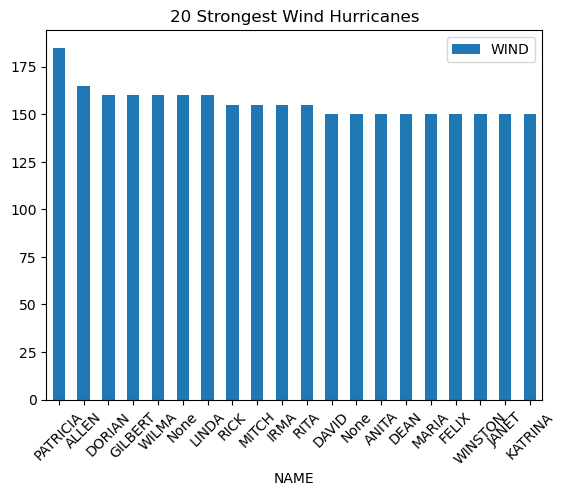

In [16]:
top20 = df.groupby('SID').agg({
    'WIND': 'max',
    'NAME': 'first'
}).sort_values('WIND', ascending=False).head(20)

top20.plot(kind='bar', x='NAME', y='WIND')
plt.xticks(rotation=45)
plt.title('20 Strongest Wind Hurricanes')
plt.show()

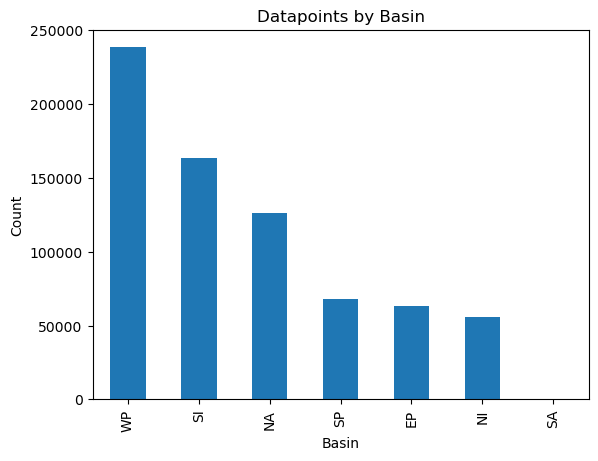

In [17]:
df['BASIN'].value_counts().plot(kind='bar')
plt.title('Datapoints by Basin')
plt.xlabel('Basin')
plt.ylabel('Count')
plt.show()

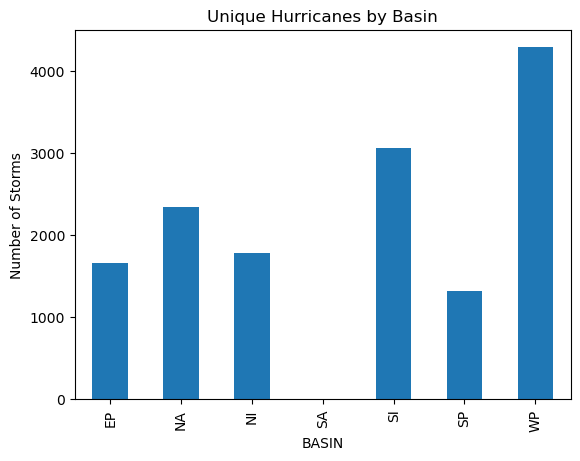

In [18]:
df.groupby('BASIN')['SID'].nunique().plot(kind='bar')
plt.title('Unique Hurricanes by Basin')
plt.ylabel('Number of Storms')
plt.show()

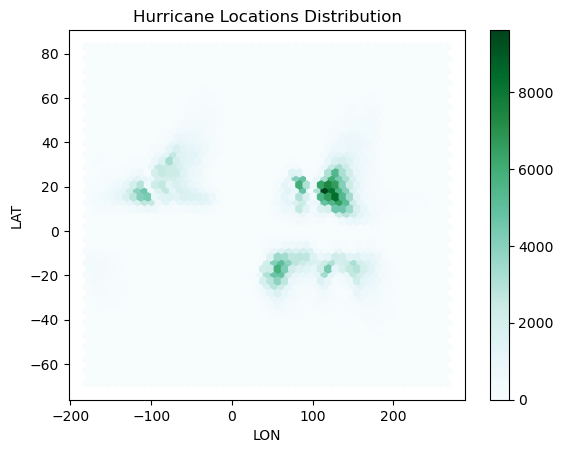

In [19]:
df.plot.hexbin(x='LON', y='LAT', gridsize=50)
plt.title('Hurricane Locations Distribution')
plt.show()

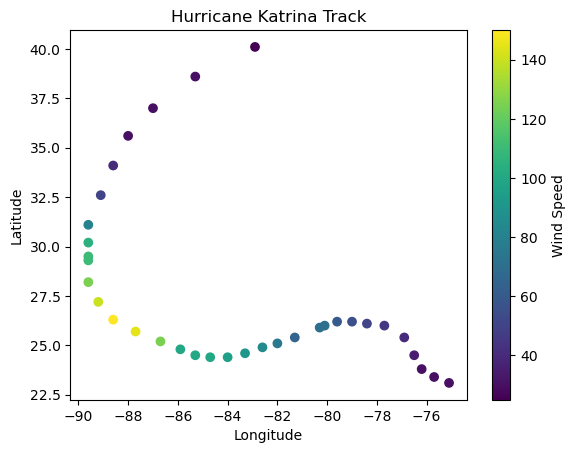

In [20]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]
katrina_sid = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].iloc[0]
katrina = df[df['SID'] == katrina_sid]
plt.scatter(katrina['LON'], katrina['LAT'], c=katrina['WIND'])
plt.colorbar(label='Wind Speed')
plt.title('Hurricane Katrina Track')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [21]:
df = df.set_index('ISO_TIME')

/tmp/ipykernel_604249/1798385018.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_counts = df['SID'].resample('Y').count()


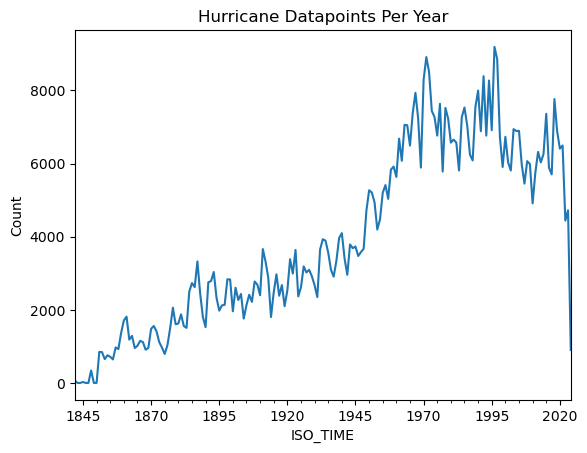

In [22]:
yearly_counts = df['SID'].resample('Y').count()

yearly_counts.plot()
plt.title('Hurricane Datapoints Per Year')
plt.ylabel('Count')
plt.show()